In [1]:
from PIL.ImageChops import offset
from mpmath import residual
from plotnine.options import aspect_ratio
from pysb.examples.run_bax_pore_sequential import color
from sympy.abc import alpha

from dmm.config_options import Conf
from evaluate_all import cell_line
from util import load_petab_base_files

DATA = "dream_cytof"
MODEL = "EGFR_MAPK"

# updated load_petab_base_files takes in Conf object
conf = Conf(model=MODEL, data=DATA)
files = load_petab_base_files(conf)

In [2]:
df = files["measurement_table"]

In [3]:
import petab

df = df[df[petab.OBSERVABLE_ID].isin(["pERK_Y204_obs", "pMEK_S222_obs", "pERBB2_Y1248_obs"])]

In [4]:
df

,observableId,preequilibrationConditionId,time,measurement,noiseParameters,simulationConditionId,measurementType,observableParameters
22548,pERK_Y204_obs,c184A1,0.0,2.651779,0.865540,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset
22549,pERK_Y204_obs,c184A1,0.0,2.622569,0.853603,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset
22550,pERK_Y204_obs,c184A1,5.5,3.609992,0.774486,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset
22551,pERK_Y204_obs,c184A1,7.0,3.541978,0.747820,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset
22552,pERK_Y204_obs,c184A1,9.0,3.792992,0.713831,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset
...,...,...,...,...,...,...,...,...
39438,pMEK_S222_obs,cZR7530,9.0,3.121920,0.535655,cZR7530__iMEK,cytof,pMEK_S222_obs_scale;pMEK_S222_obs_offset
39439,pMEK_S222_obs,cZR7530,13.0,3.061890,0.582387,cZR7530__iMEK,cytof,pMEK_S222_obs_scale;pMEK_S222_obs_offset
39440,pMEK_S222_obs,cZR7530,17.0,3.105215,0.595525,cZR7530__iMEK,cytof,pMEK_S222_obs_scale;pMEK_S222_obs_offset
39441,pMEK_S222_obs,cZR7530,40.0,3.311980,0.558350,cZR7530__iMEK,cytof,pMEK_S222_obs_scale;pMEK_S222_obs_offset


In [5]:
df.shape

(3178, 8)

In [6]:
df["perturbation"] = df[petab.SIMULATION_CONDITION_ID].apply(
    lambda x: x.split("__")[1]
)

/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_4585/1888843244.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["perturbation"] = df[petab.SIMULATION_CONDITION_ID].apply(


In [7]:
df

,observableId,preequilibrationConditionId,time,measurement,noiseParameters,simulationConditionId,measurementType,observableParameters,perturbation
22548,pERK_Y204_obs,c184A1,0.0,2.651779,0.865540,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
22549,pERK_Y204_obs,c184A1,0.0,2.622569,0.853603,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
22550,pERK_Y204_obs,c184A1,5.5,3.609992,0.774486,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
22551,pERK_Y204_obs,c184A1,7.0,3.541978,0.747820,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
22552,pERK_Y204_obs,c184A1,9.0,3.792992,0.713831,c184A1__EGF,cytof,pERK_Y204_obs_scale;pERK_Y204_obs_offset,EGF
...,...,...,...,...,...,...,...,...,...
39438,pMEK_S222_obs,cZR7530,9.0,3.121920,0.535655,cZR7530__iMEK,cytof,pMEK_S222_obs_scale;pMEK_S222_obs_offset,iMEK
39439,pMEK_S222_obs,cZR7530,13.0,3.061890,0.582387,cZR7530__iMEK,cytof,pMEK_S222_obs_scale;pMEK_S222_obs_offset,iMEK
39440,pMEK_S222_obs,cZR7530,17.0,3.105215,0.595525,cZR7530__iMEK,cytof,pMEK_S222_obs_scale;pMEK_S222_obs_offset,iMEK
39441,pMEK_S222_obs,cZR7530,40.0,3.311980,0.558350,cZR7530__iMEK,cytof,pMEK_S222_obs_scale;pMEK_S222_obs_offset,iMEK


In [8]:
import numpy as np
import pandas as pd

mat = pd.pivot_table(
    df,
    index=[petab.PREEQUILIBRATION_CONDITION_ID],
    columns=[petab.OBSERVABLE_ID, "perturbation", petab.TIME],
    values=[petab.MEASUREMENT],
    aggfunc=np.nanmean,
)

/var/folders/lt/n6z6ygk55q583z32lhqt4x8mg_mvwv/T/ipykernel_4585/3193559411.py:4: FutureWarning: The provided callable <function nanmean at 0x10c05a200> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  mat = pd.pivot_table(


In [9]:
mat.dropna(how="any", axis=1, inplace=True)

In [10]:
mat

measurement                                \
observableId                pERK_Y204_obs                                 
perturbation                          EGF                                 
time                                 0.0       5.5       7.0       9.0    
preequilibrationConditionId                                               
c184A1                           2.637174  3.609992  3.541978  3.712986   
cBT20                            3.875562  4.023805  4.444585  4.282082   
cBT474                           3.168340  3.386293  3.148961  3.331651   
cBT549                           2.861028  3.903806  4.064274  3.836934   
cCAL148                          2.019691  3.624689  3.355717  3.557879   
cCAL51                           2.691943  4.086462  3.889014  3.971399   
cCAL851                          3.371487  3.865519  3.596084  3.875296   
cDU4475                          3.378883  3.340068  2.700998  3.131279   
cEFM192A                         2.688033  3.032265  3.234679  3.253509   
cEVSAT                           1.819923  2.652098  2.552936  2.451859   
cHBL100                          3.019159  4.062572  4.236452  3.800517   
cHCC1187                         3.340793  4.194150  3.994865  4.124937   
cHCC1395                         2.273531  3.925233  3.722100  3.681735   
cHCC1419                         3.834137  4.102450  3.434090  3.583030   
cHCC1500                         2.258435  2.400839  1.800813  2.007820   
cHCC1569                         2.832013  3.999610  3.923995  3.786145   
cHCC1937                         3.793918  4.772590  4.624025  4.571870   
cHCC1954                         3.368196  4.375015  3.991009  4.094956   
cHCC2185                         3.252448  3.806803  3.691876  3.794145   
cHCC3153                         3.767280  4.241894  4.085425  3.874140   
cHCC38                           4.533368  4.883223  4.873012  4.757068   
cHCC70                           3.346255  3.824050  4.249020  3.790463   
cHDQP1                           3.664360  4.163098  4.186591  4.138422   
cJIMT1                           3.250930  3.956613  3.467057  3.713786   
cMCF10A                          2.126778  3.556497  3.726556  3.681700   
cMCF7                            1.730069  2.542658  2.762958  2.519239   
cMDAMB134VI                      3.000928  3.184427  3.031164  2.973427   
cMDAMB157                        2.801727  4.355323  4.263620  4.123174   
cMDAMB175VII                     3.220495  4.018837  3.908902  3.985144   
cMDAMB361                        2.164013  3.884385  3.824195  3.729660   
cMDAMB415                        3.318313  2.736965  2.523312  2.144061   
cMDAMB453                        2.976775  3.831305  3.827920  3.639745   
cMFM223                          3.493586  3.643193  3.148321  3.007925   
cMPE600                          3.178826  3.332797  3.279481  3.200908   
cMX1                             2.775899  3.909343  3.741988  3.825738   
cOCUBM                           2.700817  4.383023  4.056429  3.813819   
cT47D                            1.926186  3.806318  3.794728  3.797036   
cUACC812                         2.940479  3.242884  3.183776  3.210295   
cUACC893                         2.637330  3.851615  3.932550  3.637985   
cZR7530                          3.461186  3.477676  3.523090  3.416004   

                                                                               \
observableId                                                                    
perturbation                                                            iEGFR   
time                             17.0      23.0      30.0      60.0      0.0    
preequilibrationConditionId                                                     
c184A1                       3.349887  3.676944  3.264372  2.807897  2.328540   
cBT20                        4.571664  3.963559  4.559575  4.190396  3.284543   
cBT474                       3.284709  3.040432  3.232934  3.121649  2.031925   
cBT549

In [11]:
mat - mat.mean(axis=0)  # mat.mean(axis=0) is the average (for a specific perturbation, observable, timepoint) across ALL cell-lines

measurement                                \
observableId                pERK_Y204_obs                                 
perturbation                          EGF                                 
time                                 0.0       5.5       7.0       9.0    
preequilibrationConditionId                                               
c184A1                          -0.350333 -0.139768 -0.091485  0.117242   
cBT20                            0.888055  0.274045  0.811122  0.686338   
cBT474                           0.180832 -0.363466 -0.484502 -0.264094   
cBT549                          -0.126480  0.154046  0.430810  0.241190   
cCAL148                         -0.967816 -0.125071 -0.277747 -0.037866   
cCAL51                          -0.295564  0.336702  0.255550  0.375655   
cCAL851                          0.383980  0.115759 -0.037380  0.279551   
cDU4475                          0.391376 -0.409692 -0.932466 -0.464465   
cEFM192A                        -0.299475 -0.717495 -0.398785 -0.342235   
cEVSAT                          -1.167585 -1.097662 -1.080528 -1.143885   
cHBL100                          0.031652  0.312812  0.602988  0.204772   
cHCC1187                         0.353285  0.444390  0.361401  0.529193   
cHCC1395                        -0.713976  0.175473  0.088636  0.085990   
cHCC1419                         0.846630  0.352690 -0.199374 -0.012714   
cHCC1500                        -0.729072 -1.348921 -1.832651 -1.587924   
cHCC1569                        -0.155495  0.249850  0.290531  0.190401   
cHCC1937                         0.806410  1.022830  0.990561  0.976126   
cHCC1954                         0.380689  0.625255  0.357545  0.499211   
cHCC2185                         0.264941  0.057043  0.058412  0.198401   
cHCC3153                         0.779773  0.492134  0.451961  0.278396   
cHCC38                           1.545861  1.133463  1.239549  1.161324   
cHCC70                           0.358748  0.074290  0.615556  0.194718   
cHDQP1                           0.676853  0.413338  0.553127  0.542678   
cJIMT1                           0.263423  0.206853 -0.166407  0.118042   
cMCF10A                         -0.860729 -0.193262  0.093092  0.085956   
cMCF7                           -1.257439 -1.207101 -0.870506 -1.076505   
cMDAMB134VI                      0.013421 -0.565333 -0.602300 -0.622317   
cMDAMB157                       -0.185780  0.605563  0.630156  0.527430   
cMDAMB175VII                     0.232988  0.269077  0.275438  0.389400   
cMDAMB361                       -0.823495  0.134625  0.190731  0.133916   
cMDAMB415                        0.330805 -1.012795 -1.110151 -1.451683   
cMDAMB453                       -0.010732  0.081545  0.194456  0.044001   
cMFM223                          0.506078 -0.106567 -0.485143 -0.587819   
cMPE600                          0.191319 -0.416963 -0.353983 -0.394836   
cMX1                            -0.211608  0.159583  0.108524  0.229994   
cOCUBM                          -0.286691  0.633263  0.422965  0.218075   
cT47D                           -1.061321  0.056559  0.161265  0.201291   
cUACC812                        -0.047028 -0.506876 -0.449688 -0.385449   
cUACC893                        -0.350177  0.101855  0.299086  0.042241   
cZR7530                          0.473679 -0.272084 -0.110374 -0.179740   

                                                                               \
observableId                                                                    
perturbation                                                            iEGFR   
time                             17.0      23.0      30.0      60.0      0.0    
preequilibrationConditionId                                                     
c184A1                       0.008381  0.342579 -0.026420 -0.345099 -0.268924   
cBT20                        1.230158  0.629194  1.268782  1.037400  0.687079   
cBT474                      -0.056797 -0.293933 -0.057858 -0.031347 -0.565539   
cBT549

In [84]:
res = (mat - mat.mean(axis=0)).apply(lambda x: np.power(x, 2)).mean(axis=1)
res

preequilibrationConditionId
c184A1          0.097351
cBT20           0.688124
cBT474          0.090133
cBT549          0.159124
cCAL148         0.147106
cCAL51          0.129771
cCAL851         0.059733
cDU4475         0.470586
cEFM192A        0.212074
cEVSAT          0.547837
cHBL100         0.051129
cHCC1187        0.240270
cHCC1395        0.112628
cHCC1419        0.155670
cHCC1500        0.664514
cHCC1569        0.122809
cHCC1937        0.479509
cHCC1954        0.244542
cHCC2185        0.505282
cHCC3153        0.065887
cHCC38          0.484470
cHCC70          0.122960
cHDQP1          0.312700
cJIMT1          0.228992
cMCF10A         0.134313
cMCF7           0.731856
cMDAMB134VI     0.247603
cMDAMB157       0.303896
cMDAMB175VII    0.343427
cMDAMB361       0.361376
cMDAMB415       0.346464
cMDAMB453       0.166603
cMFM223         0.311536
cMPE600         0.058216
cMX1            0.086041
cOCUBM          0.131522
cT47D           0.144300
cUACC812        0.207618
cUACC893        0.2200

In [85]:
res.sort_values(ascending=False).head(10)
# top 5 cell-lines for deviation from the mean: cMCF7, cBT20, cHCC1500, cEVSAT, cHCC2185 -> 5 CV splits
# following 5: cHCC38, cHCC1937, cDU4475, cMDAMB361, cMDAMB415

preequilibrationConditionId
cMCF7        0.731856
cBT20        0.688124
cHCC1500     0.664514
cEVSAT       0.547837
cHCC2185     0.505282
cHCC38       0.484470
cHCC1937     0.479509
cDU4475      0.470586
cMDAMB361    0.361376
cMDAMB415    0.346464
dtype: float64

In [86]:
res.sort_values(ascending=False).index.tolist()

['cMCF7',
 'cBT20',
 'cHCC1500',
 'cEVSAT',
 'cHCC2185',
 'cHCC38',
 'cHCC1937',
 'cDU4475',
 'cMDAMB361',
 'cMDAMB415',
 'cMDAMB175VII',
 'cHDQP1',
 'cMFM223',
 'cMDAMB157',
 'cZR7530',
 'cMDAMB134VI',
 'cHCC1954',
 'cHCC1187',
 'cJIMT1',
 'cUACC893',
 'cEFM192A',
 'cUACC812',
 'cMDAMB453',
 'cBT549',
 'cHCC1419',
 'cCAL148',
 'cT47D',
 'cMCF10A',
 'cOCUBM',
 'cCAL51',
 'cHCC70',
 'cHCC1569',
 'cHCC1395',
 'c184A1',
 'cBT474',
 'cMX1',
 'cHCC3153',
 'cCAL851',
 'cMPE600',
 'cHBL100']

<Axes: ylabel='Frequency'>

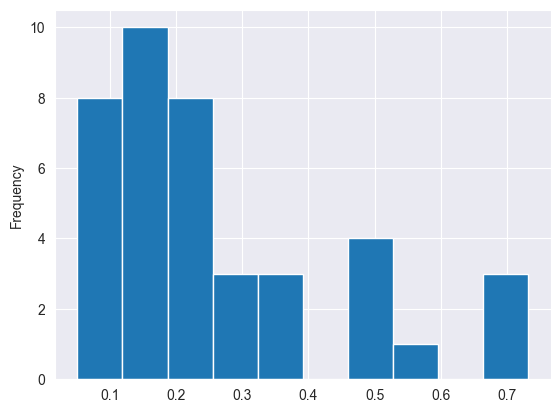

In [87]:
res.plot.hist()

In [88]:
list(res[res.values > 2].index)  # only cell-line, 'cHCC1599', has already been dropped as outlier

[]

In [89]:
mat.drop(list(res[res.values > 2].index), axis=0, inplace=True)

In [90]:
X = mat.values
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
Xt = pca.fit_transform(X)

In [91]:
Xt.shape  # it appears 3 other cell-lines have been dropped (no transcriptomic data), previous notebook had 43 remaining cell-lines

(40, 10)

In [92]:
X.shape

(40, 34)

In [93]:
Xt[:, 0]

array([-0.26730243, -4.31403742,  1.17694124, -0.6630489 ,  0.4107871 ,
       -0.96583191, -0.34648384, -0.52225357,  2.04531798,  3.94312077,
       -0.40805694, -2.43462873,  0.22597166,  0.86112878,  4.39851306,
       -0.53001061, -3.14720332, -2.34484942, -2.96001407, -0.51530051,
       -3.67357515, -0.06419554, -2.948019  , -1.78546578,  0.50857296,
        4.78871765,  1.82205151, -1.91328201, -0.97037761,  2.56104252,
        2.52796639,  0.84226751, -0.84471385,  0.14628624,  0.24508334,
        0.42214026, -0.26559217,  1.92697453,  1.96756108,  1.0637982 ])

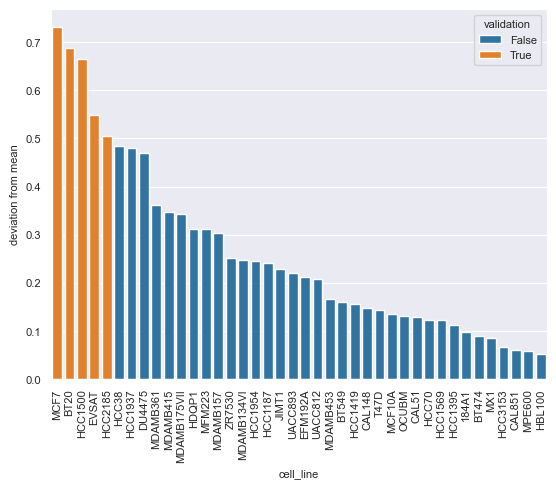

In [141]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 8})
res.name = "deviation from mean"
res.index.name = "cell_line"
res_df = res.reset_index()
res_df[res.index.name] = res_df[res.index.name].apply(lambda x: x[1:])
threshold = res.sort_values(ascending=False).head(5).min()
res_df["validation"] = res_df[res.name] >= threshold
res_df.sort_values(res.name, ascending=False, inplace=True)
sns.barplot(res_df, x=res.index.name, y=res.name, hue="validation", dodge=False)
# rotate x-axis labels
plt.xticks(rotation=90)
# decrease font size
res_df.set_index(res.index.name, inplace=True)

In [130]:
res_df.index

Index(['MCF7', 'BT20', 'HCC1500', 'EVSAT', 'HCC2185', 'HCC38', 'HCC1937',
       'DU4475', 'MDAMB361', 'MDAMB415', 'MDAMB175VII', 'HDQP1', 'MFM223',
       'MDAMB157', 'ZR7530', 'MDAMB134VI', 'HCC1954', 'HCC1187', 'JIMT1',
       'UACC893', 'EFM192A', 'UACC812', 'MDAMB453', 'BT549', 'HCC1419',
       'CAL148', 'T47D', 'MCF10A', 'OCUBM', 'CAL51', 'HCC70', 'HCC1569',
       'HCC1395', '184A1', 'BT474', 'MX1', 'HCC3153', 'CAL851', 'MPE600',
       'HBL100'],
      dtype='object', name='cell_line')

In [142]:
N_COMPS = 2
df = pd.DataFrame(
    index=[c[1:] for c in mat.index],
    data=Xt[:, :N_COMPS],
    columns=["PC1", "PC2"],
)
df.index.name = res.index.name
# select 5 strongest outliers as validation set
df["validation"] = res_df["validation"]
df

,PC1,PC2,validation
cell_line,,,
184A1,-0.267302,0.402370,False
BT20,-4.314037,-1.591901,True
BT474,1.176941,0.475074,False
BT549,-0.663049,1.939969,False
CAL148,0.410787,1.528519,False
CAL51,-0.965832,1.394326,False
CAL851,-0.346484,0.685369,False
DU4475,-0.522254,2.979289,False
EFM192A,2.045318,-1.122064,False


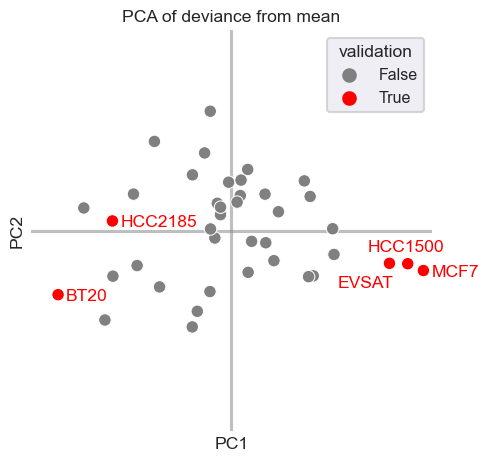

In [192]:
sns.set_context("talk", font_scale=0.7)
g = sns.scatterplot(
    data=df, 
    x="PC1", 
    y="PC2", 
    hue="validation", 
    palette=["gray", "red"],
    
)
# add cell-line labels for 5 validation cell-lines
for _, r in df.iterrows():
    if r.validation:
        ox = 0.2
        oy = -0.15
        if r.name == "EVSAT":
            ox = -1.3
            oy = -0.6
        if r.name == "HCC1500":
            ox = -1.0
            oy = 0.3
        plt.annotate(r.name, (r.PC1+ox, r.PC2+oy), color="red")

# export with transparent background and high dpi, remove grid
# no box around plot
# add dashed line at 0 for both axes with low zorder to ensure it is behind the data points
# make plot square
# make axis limits equal and remove axis labels
g.set(xlim=(-5, 5), ylim=(-5, 5), aspect=1.0, xticks=[], yticks=[])
# 
plt.axhline(0, color='gray', zorder=0, alpha=0.5)
plt.axvline(0, color='gray', zorder=0, alpha=0.5)
plt.box(False)
plt.grid(False)
plt.title("PCA of deviance from mean")
plt.tight_layout()
plt.savefig("cytof_pca.png", transparent=True, dpi=300)


In [23]:
pca.explained_variance_ratio_

array([0.48622577, 0.175565  , 0.09763937, 0.05961791, 0.05388973,
       0.03049121, 0.01976171, 0.0163276 , 0.01099675, 0.00872147])

In [24]:
pca.components_.shape

(10, 34)

In [25]:
pc_mat = pd.DataFrame(
    index=[f"PC{i}" for i in np.arange(N_COMPS)],
    data=pca.components_[:N_COMPS, :],
    columns=mat.columns,
)
pc_mat

measurement                                                    \
observableId pERK_Y204_obs                                                     
perturbation           EGF                                                     
time                  0.0       5.5       7.0       9.0       17.0      23.0   
PC0              -0.193955 -0.212588 -0.218844 -0.229778 -0.271891 -0.234896   
PC1              -0.056581  0.005553 -0.000991  0.017454  0.044337  0.025578   
PC2               0.188703 -0.257922 -0.349351 -0.304404 -0.075082 -0.020425   

                                                      ...                \
observableId                                          ... pMEK_S222_obs   
perturbation                         iEGFR            ...           EGF   
time              30.0      60.0      0.0       7.0   ...          60.0   
PC0          -0.274330 -0.235499 -0.183656 -0.273345  ...     -0.071652   
PC1          -0.005444  0.017823  0.128892  0.151613  ...     -0.215688   
PC2          -0.027241  0.092254  0.323074 -0.357893  ...      0.053150   

                                                                          \
observableId                                                               
perturbation     iEGFR                                                     
time              0.0       7.0       9.0       17.0      40.0      60.0   
PC0          -0.048000 -0.110212 -0.086634 -0.061005 -0.065392 -0.066575   
PC1          -0.190939 -0.171126 -0.230155 -0.165692 -0.243577 -0.226093   
PC2           0.116084 -0.006419  0.034646  0.069230  0.059170  0.089146   

                                            
observableId                                
perturbation      iMEK                      
time              0.0       9.0       60.0  
PC0          -0.055560 -0.085970 -0.114423  
PC1          -0.218511 -0.213176 -0.232354  
PC2           0.081504 -0.067914 -0.055272  

[3 rows x 34 columns]

In [26]:
pc_mat_long = pd.melt(pc_mat.reset_index(), id_vars="index")
pc_mat_long

KeyError: "The following id_vars or value_vars are not present in the DataFrame: ['index']"

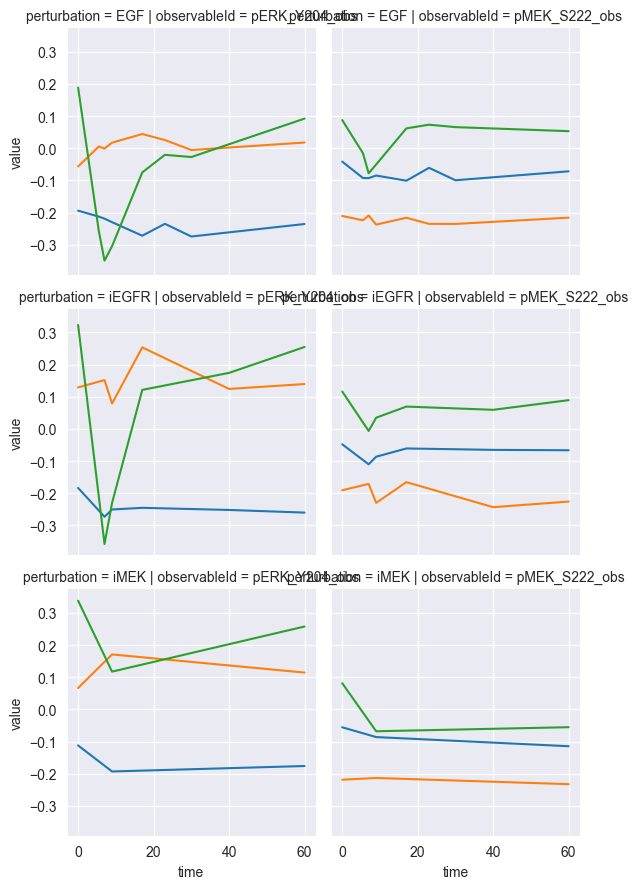

In [25]:
import seaborn as sns

g = sns.FacetGrid(
    data=pc_mat_long, col=petab.OBSERVABLE_ID, row="perturbation", hue="index"
)
g.map_dataframe(sns.lineplot, x="time", y="value")
# Previous notebook showed 5 perturbation, but we have now removed iPI3K and iPKC -> 3 left (EGF, iEGFR, iMEK)